<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/main/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [1]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


# Scatter plot

This scatter plot examines whether students who consult AI chatbots more frequently when stuck also tend to agree that AI does not interfere with their confidence in their own work. This directly targets the "trust in own efforts" side of our research question. If heavy chatbot users believe AI isn't affecting their sense of ownership over their work, it suggests a disconnect between actual reliance and self-awareness of that reliance.

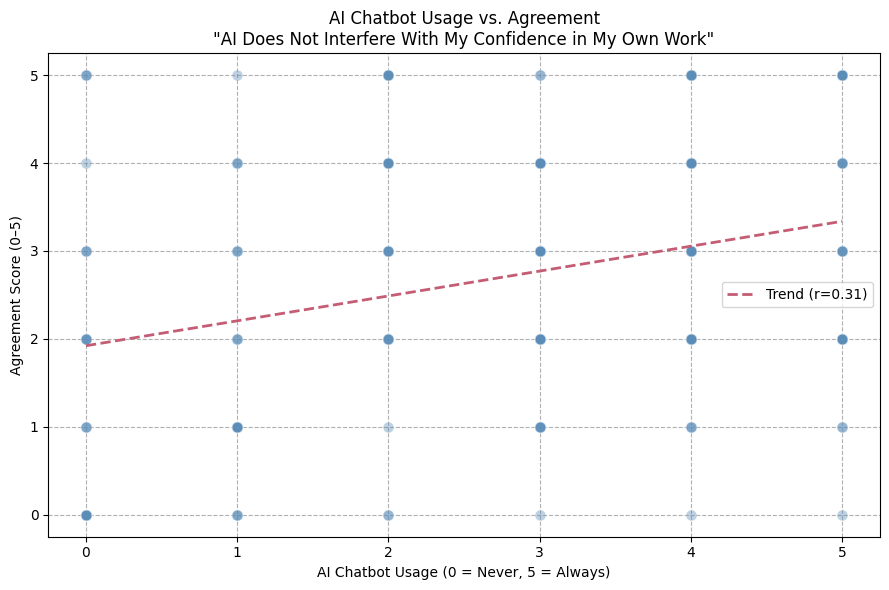

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scatter_df = df[['AI Chatbot Usage', 'Agreement']].dropna()

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(scatter_df['AI Chatbot Usage'], scatter_df['Agreement'],
           alpha=0.4, edgecolors='white', linewidth=0.4, s=60, color='#5B8DB8')

x = scatter_df['AI Chatbot Usage'].values.astype(float)
y = scatter_df['Agreement'].values.astype(float)
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
m, b = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='#C45C74', linewidth=2, linestyle='--', label=f'Trend (r={r:.2f})')

ax.set_xlabel('AI Chatbot Usage (0 = Never, 5 = Always)')
ax.set_ylabel('Agreement Score (0–5)')
ax.set_title('AI Chatbot Usage vs. Agreement\n"AI Does Not Interfere With My Confidence in My Own Work"')
ax.set_xticks(range(0, 6))
ax.set_yticks(range(0, 6))
ax.grid(linestyle='--')
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

The trend line shows a slight positive slope with r = 0.30, meaning students who rely on AI chatbots more frequently also tend to agree more strongly that AI does not interfere with their confidence in their own work. While the correlation is weak to moderate, the direction is consistent and meaningful in the context of our research question. The most important observation is not the strength of the correlation but what it implies. Students who are most dependent on AI chatbots are simultaneously the most convinced that this dependency isn't affecting them. This mirrors the blind spot finding from our heatmap, where heavy AI users scored lower on actual confidence measures yet still agreed that AI wasn't interfering. The scatter plot makes this pattern visible at the individual student level, showing that high chatbot users (x = 4 or 5) are concentrated in the upper half of the agreement scale rather than the lower half. This suggests that frequent AI chatbot use may create a false sense of confidence, where students feel capable and trust their own work while their self-assessed skills without AI are actually lower than those of students who use AI less.

# Average confidence level vs AI usage Line Plot

This line plot examines whether students who use AI more heavily for CS coursework show lower self-confidence across different academic skill areas. By plotting all five confidence types on the same chart, we can see not only whether the trend is negative overall but also which skill areas are most affected by higher AI use and whether some confidence types are more resilient than others.

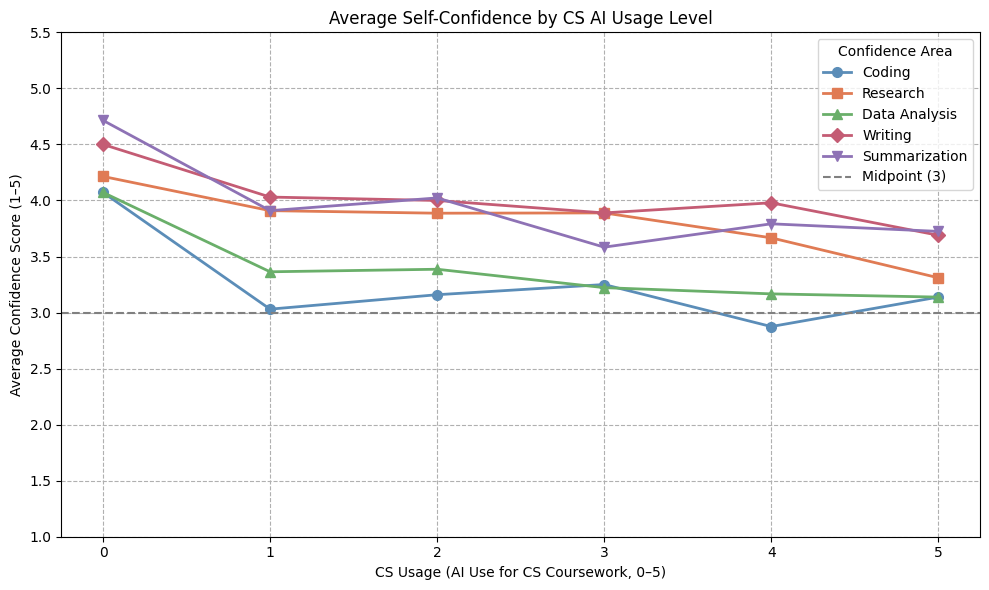

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conf_map = {'Slightly Confident': 1, 'Somewhat Confident': 2, 'Fairly Confident': 3,
            'Mostly Confident': 4, 'Very Confident': 5}

for col, new in [('Coding Self Confidence','Coding'),
                 ('Research Self Confidence','Research'),
                 ('Data Analysis Self Confidence','Data Analysis'),
                 ('Writing Self Confidence','Writing'),
                 ('Topic Summarization Self Confidence','Summarization')]:
    df[new] = df[col].map(conf_map)

cs_means = df.groupby('CS Usage')[['Coding','Research','Data Analysis','Writing','Summarization']].mean()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#5B8DB8', '#E07B54', '#6AAF6A', '#C45C74', '#8E72B5']
markers = ['o', 's', '^', 'D', 'v']
for (col, color, marker) in zip(cs_means.columns, colors, markers):
    ax.plot(cs_means.index, cs_means[col], color=color, marker=marker,
            linewidth=2, markersize=7, label=col)

ax.set_xlabel('CS Usage (AI Use for CS Coursework, 0–5)')
ax.set_ylabel('Average Confidence Score (1–5)')
ax.set_title('Average Self-Confidence by CS AI Usage Level')
ax.set_xticks(cs_means.index)
ax.set_ylim(1, 5.5)
ax.axhline(3, color='gray', linestyle='--', label='Midpoint (3)')
ax.grid(linestyle='--')
ax.set_axisbelow(True)
ax.legend(title='Confidence Area', loc='upper right')
plt.tight_layout()
plt.show()

The overall pattern across all five confidence types shows a general downward trend as CS usage increases, which supports our hypothesis that heavier AI use for coursework is associated with lower self-confidence. Data Analysis Confidence shows the steepest decline, dropping noticeably from lower to higher usage levels, which makes intuitive sense since data analysis is directly related to CS coursework where AI is being used. Coding Confidence follows a similar pattern. Notably all five confidence lines sit above the midpoint of 3 across most usage levels, meaning students are generally confident in their abilities regardless of AI use. However the gap between low and high usage students is consistent enough across all skill areas. And not just technical ones like coding and data analysis but also writing, research, and summarization, suggesting that heavy AI use in CS is associated with a broader reduction in academic self-confidence rather than just a technical one. This is a key finding because it implies the effect of AI use on confidence extends beyond the subject where AI is actually being used.

# Hypothesis

There is a significant association between AI usage levels and whether students are concerned about overreliance on AI

In [21]:
import pandas as pd
import numpy as np

concern_map = {
    "1 (Not at all/haven't thought about it)": 1,
    '2 (Somewhat influential)': 2,
    '3 (Partially Influential)': 3,
    '4 (Moderately influential)': 4,
    '5 (Extremely influential)': 5
}

df['Overreliance_num'] = df['Overreliance Concern'].map(concern_map)
df['Concern_Group'] = df['Overreliance_num'].apply(lambda x: 'High (4-5)' if x >= 4 else 'Low (1-3)')

df['AI_Use_Score'] = df[['CS Usage','Math Usage','Data Science Usage','AI Chatbot Usage']].mean(axis=1)

def ai_group(s):
    if s <= 2: return 'Low'
    elif s <= 3.5: return 'Medium'
    else: return 'High'

df['AI_Use_Level'] = df['AI_Use_Score'].apply(ai_group)

contingency = pd.crosstab(df['AI_Use_Level'], df['Concern_Group'])
print(contingency)

observed = contingency.values
row_totals = observed.sum(axis=1, keepdims=True)
col_totals = observed.sum(axis=0, keepdims=True)
total = observed.sum()

expected = (row_totals * col_totals) / total
chi2 = ((observed - expected) ** 2 / expected).sum()
dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)

def chi2_cdf(x, k):
    z = ((x / k) ** (1/3) - (1 - 2/(9*k))) / np.sqrt(2/(9*k))
    return 1 - 0.5 * (1 + np.sign(z) * (1 - np.exp(-0.717*abs(z) - 0.416*z**2)))

p_approx = 1 - chi2_cdf(chi2, dof)

print(f'\nChi2: {chi2:.3f}')
print(f'Degrees of Freedom: {dof}')
print(f'P-value (approx): {p_approx:.3f}')

Concern_Group  High (4-5)  Low (1-3)
AI_Use_Level                        
High                   41         12
Low                    51         19
Medium                 61         20

Chi2: 0.333
Degrees of Freedom: 2
P-value (approx): 0.157


The chi-squared test returned a value of 0.333 with 2 degrees of freedom and a p-value of 0.157. Since the p-value is greater than 0.05, the result is not statistically significant. We fail to reject the null hypothesis and cannot conclude that there is a meaningful association between AI use level and overreliance concern.